In [422]:
#Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [423]:
#Load dataset
df = pd.read_csv("GSE68086_TEP_data_matrix.csv")

#Set gene IDs as index
df = df.set_index(df.columns[0])

#Transpose so rows=samples, columns=genes
df = df.T

print("Shape after transpose:", df.shape)

Shape after transpose: (285, 57736)


In [424]:
#Extract cancer type from sample name
y = df.index.str.split("-").str[1]

X = df.copy()

print("Unique classes:", np.unique(y))

Unique classes: ['0001' '0007' '0012' '0014J' '0015' '0016' '0017' '0020J' '0024J' '0025J'
 '0026J' '0029J' '0030J' '0037' '004' '0040' '0042' '0046' '0058' '006'
 '0061' '0062' '0074' '008' '0082' '0096' '0100' '0101' '0102' '0104'
 '0110' '0112' '0119' '1' '10' '100' '11' '13' '14' '15' '16' '17' '18'
 '2' '20' '21' '22' '24' '25' '26' '27' '29' '3' '30' '31' '32' '33' '335'
 '34' '35' '357' '36' '37' '370' '38' '39' '4' '40' '410' '435' '438' '44'
 '440' '442' '45' '450' '451' '454' '459' '46' '460' '461' '463' '47'
 '471' '475' '476' '477' '48' '480' '484' '485' '486' '487' '49' '493'
 '496' '499' '5' '50' '501' '503' '505' '51' '511' '523' '524' '53' '531'
 '54' '552' '564' '565' '576' '590' '593' '597' '6' '60' '603' '611' '7'
 '8' '85' '86' '9' 'ALK' 'BrCa' 'Breast' 'CRC' 'GBM' 'L' 'Liver' 'NSCLC'
 'Pancr' 'Unknown' 'hiseq']


In [425]:
#Select three cancer types
selected_classes = ['Breast','NSCLC','CRC']

mask = y.isin(selected_classes)

X_3class = X[mask]
y_3class = y[mask]

print("Shape:", X_3class.shape)
print("Classes:", np.unique(y_3class))


Shape: (65, 57736)
Classes: ['Breast' 'CRC' 'NSCLC']


In [426]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_3class,y_3class,test_size=0.3,random_state=42,stratify=y_3class)

In [427]:
#Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**CASE A:Without LDA**

In [428]:
#Train SVM on full 57k genes
svm_original = SVC(kernel='rbf', random_state=42)

svm_original.fit(X_train_scaled, y_train)

y_pred_original = svm_original.predict(X_test_scaled)

accuracy_original = accuracy_score(y_test, y_pred_original)

print("Accuracy WITHOUT LDA:", accuracy_original)

Accuracy WITHOUT LDA: 0.55


In [429]:
#Compute variance before LDA
variance_before = np.var(X_train_scaled, axis=0)

#Total variance before LDA
total_variance_before = np.sum(variance_before)

print("Number of original features:", X_train_scaled.shape[1])
print("Average variance BEFORE LDA:", np.mean(variance_before))
print("Total variance BEFORE LDA:", total_variance_before)

Number of original features: 57736
Average variance BEFORE LDA: 0.32586254676458365
Total variance BEFORE LDA: 18814.0


Shape after PCA: (45, 2)


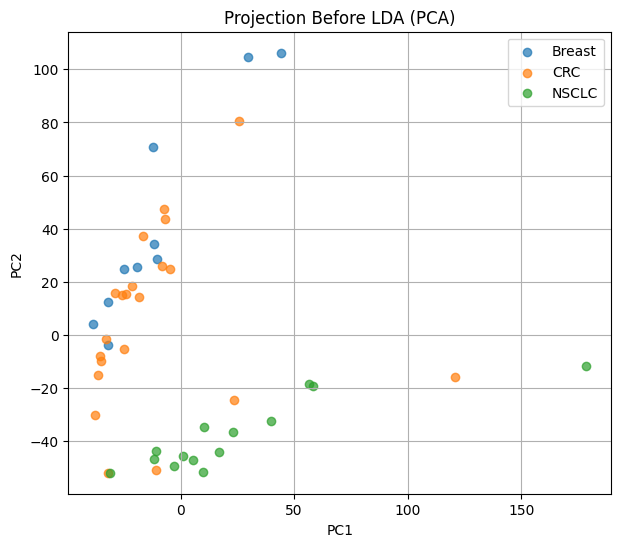

In [430]:
#Import PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#Apply PCA before LDA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
print("Shape after PCA:", X_train_pca.shape)

#Scatter plot before LDA (PCA projection)
plt.figure(figsize=(7,6))

for cls in np.unique(y_train):
    plt.scatter(
        X_train_pca[y_train==cls,0],
        X_train_pca[y_train==cls,1],
        label=cls,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection Before LDA (PCA)")
plt.legend()
plt.grid(True)
plt.show()

**CASE B:WITH LDA**

In [431]:
#Apply LDA for 3 classes
lda = LinearDiscriminantAnalysis(n_components=2)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print("Shape after LDA:", X_train_lda.shape)


Shape after LDA: (45, 2)


In [432]:
#Train SVM on LDA-reduced data
svm_lda = SVC(kernel='rbf', random_state=42)

svm_lda.fit(X_train_lda, y_train)

y_pred_lda = svm_lda.predict(X_test_lda)

accuracy_lda = accuracy_score(y_test, y_pred_lda)

print("Accuracy WITH LDA:", accuracy_lda)

Accuracy WITH LDA: 0.7


In [433]:
#Compute variance after LDA
variance_after = np.var(X_train_lda, axis=0)

total_variance_after = np.sum(variance_after)

print("Variance per LDA component:", variance_after)
print("Total variance AFTER LDA:", total_variance_after)

Variance per LDA component: [2.21513527 1.18971536]
Total variance AFTER LDA: 3.4048506283467783


In [434]:
#Compute between-class variance ratio
print("Explained discriminative variance ratio:",lda.explained_variance_ratio_)

Explained discriminative variance ratio: [0.83332161 0.16667839]


In [435]:
#Compare results
print("\n==========FINAL COMPARISON==========")

print("\n---Accuracy Comparison---")
print("Accuracy without LDA:", accuracy_original)
print("Accuracy with LDA:", accuracy_lda)

print("\n---Dimensionality---")
print("Number of features before LDA:", X_train_scaled.shape[1])
print("Number of features after LDA:", X_train_lda.shape[1])

print("\n---Variance Comparison---")
print("Total variance BEFORE LDA:", total_variance_before)
print("Total variance AFTER LDA:", total_variance_after)

print("\n---LDA Explained Variance Ratio---")
print("Explained variance ratio:", lda.explained_variance_ratio_)


==========FINAL COMPARISON==========

---Accuracy Comparison---
Accuracy without LDA: 0.55
Accuracy with LDA: 0.7

---Dimensionality---
Number of features before LDA: 57736
Number of features after LDA: 2

---Variance Comparison---
Total variance BEFORE LDA: 18814.0
Total variance AFTER LDA: 3.4048506283467783

---LDA Explained Variance Ratio---
Explained variance ratio: [0.83332161 0.16667839]


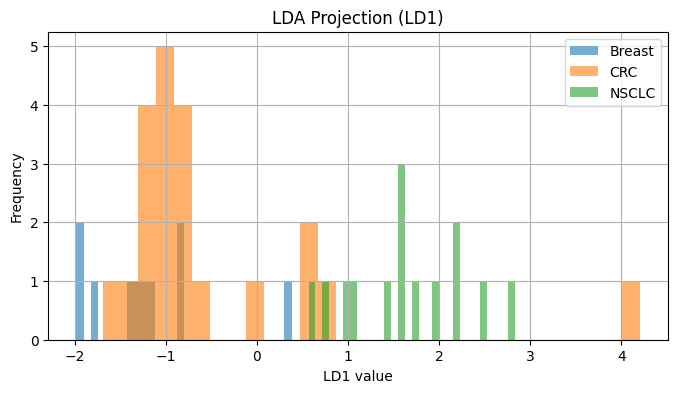

In [436]:
#Plot LD1 distribution per class
plt.figure(figsize=(8,4))

classes = np.unique(y_train)

for cls in classes:
    plt.hist(X_train_lda[y_train==cls,0],
             bins=30,
             alpha=0.6,
             label=cls)

plt.title("LDA Projection (LD1)")
plt.xlabel("LD1 value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

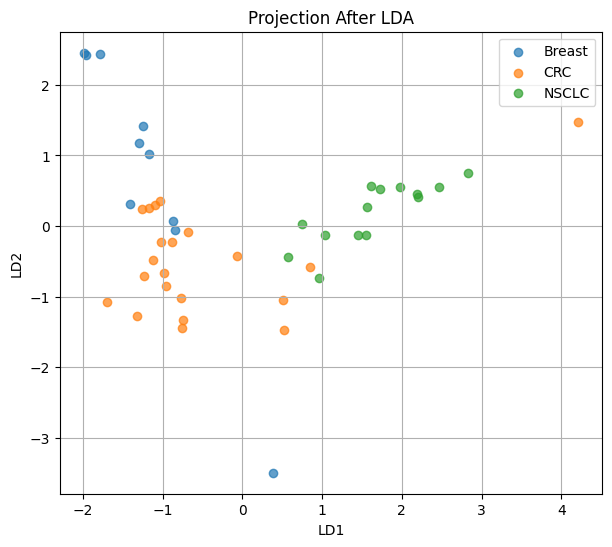

In [437]:
plt.figure(figsize=(7,6))
for cls in np.unique(y_train):
    plt.scatter(
        X_train_lda[y_train==cls,0],
        X_train_lda[y_train==cls,1],
        label=cls,
        alpha=0.7
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Projection After LDA")
plt.legend()
plt.grid(True)
plt.show()

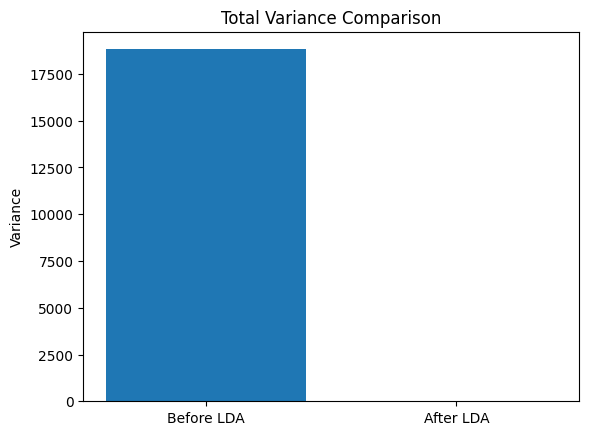

In [438]:
#Plot variance comparison
import matplotlib.pyplot as plt

plt.bar(["Before LDA","After LDA"],
        [total_variance_before,total_variance_after])

plt.title("Total Variance Comparison")
plt.ylabel("Variance")
plt.show()